In [28]:
import getpass
import os

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f'{var}: ')
    
_set_env('OPENAI_API_KEY')
_set_env('ANTHROPIC_API_KEY')

In [34]:
from dotenv import load_dotenv

load_dotenv()

True

In [35]:
from langchain_core.tools import tool
import pandas as pd

@tool
def describe_data(csv: str) -> str:
    """Describe the data column in the dataframe.
    
    Args:
        csv: csv data path string
    """
    df = pd.read_csv(csv)
    describe_str = f'''Data: {csv}''' + df.describe(include='all').to_string()
    return describe_str

In [36]:
tools = [describe_data]

In [37]:
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

llm_gpt = ChatOpenAI(model='gpt-4o-mini')
llm_with_tools = llm_gpt.bind_tools(tools, tool_choice='any')

In [38]:
response = llm_with_tools.invoke(
    'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv 이 데이터의 전처리를 해주세요.'
)

In [39]:
response.tool_calls[0]['args']

{'csv': 'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv'}

In [7]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_RBFQaf7oviIXBzURfbWbwCPg', 'function': {'arguments': '{"csv":"https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv"}', 'name': 'describe_data'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 81, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_644f11dd4d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b55e2-f933-7183-93d1-3684dad9b469-0', tool_calls=[{'name': 'describe_data', 'args': {'csv': 'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv'}, 'id': 'call_RBFQaf7oviIXBzURfbWbwCPg', 'type': 'tool_call'}], usage_metadata={'input_tokens':

In [40]:
from pydantic import BaseModel, Field

class code(BaseModel):
    '''Schema for code solutions.'''

    prefix: str = Field(description='Description of the problem and approach')
    imports: str = Field(description='Code block import statements')
    code: str = Field(description='Code block not including import statements')

In [41]:
from langchain_core.prompts import ChatPromptTemplate

GENERATE_CODE_TEMPLATE = '''
Given the following pandas `describe()` output of a dataset,

write a **directly executable Python code** to:
1. handle missing values,
2. convert categorical columns,
3. ...any additional preprocessing needed,
4. prepare the dataset for machine learning.

Here is the describe result of the dataset:
\n ------- \n {context} \n ------- \n

Do not wrap the code in a function and the response in any backticks or anything else. The code should be written as a flat script, so that it can be run immediately and any errors will be visible during execution.
Ensure any code you provide can be executed \n
with all requried imports and variables defined. Structure your answer with a description of the code solution. \n
Then list the imports. And finally list the functioning code block.
'''

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ('user', GENERATE_CODE_TEMPLATE),
    ]
)

In [42]:
from langchain_anthropic import ChatAnthropic

llm_claude = ChatAnthropic(model='claude-3-7-sonnet-20250219')

In [43]:
tool_result = describe_data.invoke(response.tool_calls[0]['args'])

In [12]:
print(tool_result)

Data: https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv       Number of times pregnant  Plasma glucose concentration a 2 hours in an oral glucose tolerance test  Diastolic blood pressure (mm Hg)  Triceps skin fold thickness (mm)  2-Hour serum insulin (mu U/ml)  Body mass index (weight in kg/(height in m)^2)  Diabetes pedigree function  Age (years)  Class variable
count                768.000000                                                                768.000000                        768.000000                        768.000000                      768.000000                                      768.000000                  768.000000   768.000000      768.000000
mean                   3.845052                                                                120.894531                         69.105469                         20.536458                       79.799479                                       31.992578                    0.471876    33.240885

In [13]:
generated_code = llm_claude.invoke(
    code_gen_prompt.format_messages(context=tool_result)
)
print('generated_code', generated_code)
code_structurer = llm_gpt.with_structured_output(code)
code_solution = code_structurer.invoke(generated_code.content)
print('code_solution', code_solution)

generated_code content='# Data Preprocessing for Diabetes Dataset\n\nBased on the `describe()` output, this dataset appears to be the Pima Indians Diabetes dataset with both numerical and categorical features. Here\'s a comprehensive preprocessing pipeline to prepare this data for machine learning:\n\n## Solution Description:\n1. **Handle Missing Values**: There are likely missing values represented by zeros in several medical measurements (glucose, blood pressure, skin thickness, insulin, BMI) where zeros don\'t make physiological sense.\n2. **Feature Scaling**: Apply standard scaling to normalize numerical features.\n3. **Separate Features and Target**: Split the dataset into features (X) and target variable (y).\n4. **Create Training and Testing Sets**: Split the data for model evaluation.\n\n## Imports:\n\n```python\nimport pandas as pd\nimport numpy as np\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.impute im

In [14]:
code_solution

code(prefix='A comprehensive preprocessing pipeline for the Pima Indians Diabetes dataset that handles missing values, scales features, and splits the dataset into training and testing sets.', imports='import pandas as pd\nimport numpy as np\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.impute import SimpleImputer\nimport matplotlib.pyplot as plt\nimport seaborn as sns', code='# Load the dataset\nurl = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv"\ndf = pd.read_csv(url)\n\n# Display basic information\nprint("Dataset Shape:", df.shape)\nprint("\\nFirst 5 rows:")\nprint(df.head())\n\n# Identify columns with zeros that likely represent missing values\nlikely_missing_cols = [\n    \'Plasma glucose concentration a 2 hours in an oral glucose tolerance test\',\n    \'Diastolic blood pressure (mm Hg)\',\n    \'Triceps skin fold thickness (mm)\',\n    \'2-Hour serum insulin (mu U/ml)\',\n 

In [15]:
code_solution.prefix

'A comprehensive preprocessing pipeline for the Pima Indians Diabetes dataset that handles missing values, scales features, and splits the dataset into training and testing sets.'

In [16]:
print(code_solution.imports)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
print(code_solution.code)

# Load the dataset
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv"
df = pd.read_csv(url)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Identify columns with zeros that likely represent missing values
likely_missing_cols = [
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
    'Diastolic blood pressure (mm Hg)',
    'Triceps skin fold thickness (mm)',
    '2-Hour serum insulin (mu U/ml)',
    'Body mass index (weight in kg/(height in m)^2)'
]

# Replace zeros with NaN in columns where zero doesn't make physiological sense
for col in likely_missing_cols:
    df[col] = df[col].replace(0, np.nan)

# Check missing values after replacement
missing_values = df.isnull().sum()
print("\nMissing values after replacing zeros with NaN:")
print(missing_values)

# Visualize the distribution of missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False

In [44]:
from langgraph.graph import StateGraph, MessagesState

class State(MessagesState): # messages
    '''
    Represents the state of our graph.

    Attributes:
        error: Binary flag for control flow to indicate whether test error was tripped
        context: Data summary
        generation: Code solution
        iterations: Number of tries
    '''

    error: str # yer or no
    context: str
    generation: str
    iterations: int

graph_builder = StateGraph(State)

In [45]:
llm_with_tools = llm_gpt.bind_tools(tools=[describe_data])

In [46]:
def chatbot(state: State):
    print('##### HI ! #####')
    response = llm_with_tools.invoke(state['messages'])
    print('첫번째 LLM 호출 결과 : ', response)
    return {'messages': [response]}

graph_builder.add_node('chatbot', chatbot)

In [47]:
def add_context(state: State):
    print('##### ADD CONTEXT #####')
    if messages := state.get('messages', []):
        message = messages[-1]
    else:
        raise ValueError('No message found in input')

    for tool_call in message.tool_calls:
        for tool in tools:
            if tool.name == tool_call['name']:
                describe_str = tool.invoke(tool_call['args'])
    
    print('데이터 통계 (context) : ', describe_str[:100])
    return {'context': describe_str}

graph_builder.add_node('add_context', add_context)

In [48]:
from langgraph.graph import END

def guardrail_route(
    state: State,
):
    '''
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    '''
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get('messages', []):
        ai_message = messages[-1]
    else:
        raise ValueError(f'No messages found in input state to tool_edge: {state}')
    if hasattr(ai_message, 'tool_calls') and len(ai_message.tool_calls) > 0:
        return 'add_context'
    return END

graph_builder.add_conditional_edges(
    'chatbot',
    guardrail_route,
    {'add_context': 'add_context', END: END}
)

In [49]:
def generate(state: State):
    print('##### GENERATING CODE SOLUTION #####')

    context = state['context']

    generated_code = llm_claude.invoke(
        code_gen_prompt.format_messages(context=context)
    )
    code_structurer = llm_gpt.with_structured_output(code)
    code_solution = code_structurer.invoke(generated_code.content)

    messages = [
        (
            'assistant',
            f'{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}',
        )
    ]

    return {'generation': code_solution, 'messages': messages}

graph_builder.add_node('generate', generate)

In [50]:
def code_check(state: State):
    print('##### CHECKING CODE #####')

    code_solution = state['generation']

    imports = code_solution.imports
    code = code_solution.code

    try:
        exec(imports)
    except Exception as e:
        print('---CODE IMPORT CHECK: FAILED---')
        error_message = [('user', f'Your solution failed the import test: {e}')]
        print('에러 메시지 : ', error_message)
        return {
            'generation': code_solution,
            'messages': error_message,
            'error': 'yes'
        }
    
    try:
        exec_globals = {}
        exec(imports + '\n' + code, exec_globals, exec_globals)
    except Exception as e:
        print('---CODE BLOCK CHECK: FAILED---')
        error_message = [('user', f'Your solution failed the code execution test: {e}')]
        print('에러 메시지 : ', error_message)
        return {
            'generation': code_solution,
            'messages': error_message,
            'error': 'yes'
        }
    
    print('---NO CODE TEST FAILURES---')
    return {
        'generation': code_solution,
        'error': 'no'
    }

graph_builder.add_node('code_check', code_check)

In [51]:
from langchain_core.prompts import ChatPromptTemplate

reflect_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            '''
            You are given an error message that occurred while running a Python script, along with the original code that produced the error.
            Provide a corrected version of the original code that resolves the issue.
            Ensure the code runs without errors and maintains the intended functionality.'''
        ),
        (
            'user',
            '''
            --- ERROR MESSAGE ---
            {error}
            --- ORIGINAL CODE ---
            {code_solution}
            ---------------------
            
            Ensure any code you provide can be executed \n
            with all required imports and variables defined. Structure your answer with a description of the code solution. \n
            Then list the imports. And finally list the functioning code block.'''
        )
    ]
)

In [52]:
def reflect(state: State):
    print('---REFLECTING CODE SOLUTION---')

    error = state['messages'][-1].content
    code_solution = state['generation']
    code_solution = f'{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}'

    corrected_code = llm_claude.invoke(reflect_prompt.format_messages(error=error, code_solution=code_solution))
    code_structurer = llm_gpt.with_structured_output(code)
    reflections = code_structurer.invoke(corrected_code.content)
    print('수정된 코드 : ', reflections)

    messages = [
        (
            'assistant',
            f'{reflections.prefix} \n Imports: {reflections.imports} \n Code: {reflections.code}',
        )
    ]

    return {'generation': reflections, 'messages': messages, 'iterations': state['iterations'] + 1}

graph_builder.add_node('reflect', reflect)

In [53]:
max_iterations = 5

In [54]:
def decide_to_finish(state: State):
    error = state['error']
    iterations = state['iterations']

    if error == 'no' or iterations == max_iterations:
        print('---DECISION: FINISH---')
        return 'end'
    else:
        print('---DECISION: RE-TRY SOLUTION---')
        return 'reflect'

In [55]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('add_context', 'generate')
graph_builder.add_edge('generate', 'code_check')
graph_builder.add_conditional_edges(
    'code_check',
    decide_to_finish,
    {
        'end': END,
        'reflect': 'reflect'
    }
)
graph_builder.add_edge('reflect', 'code_check')

graph = graph_builder.compile()

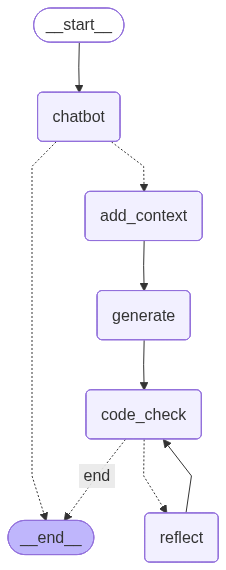

In [56]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [57]:
question = 'titanic.csv 데이터의 전처리를 부탁합니다!'

In [58]:
solution = graph.invoke({'messages': [('user', question)], 'iterations': 0, 'error': ''})

##### HI ! #####
첫번째 LLM 호출 결과 :  content='' additional_kwargs={'tool_calls': [{'id': 'call_dMyPDga83466IFZtUdp4rwZO', 'function': {'arguments': '{"csv":"titanic.csv"}', 'name': 'describe_data'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 66, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_644f11dd4d', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b55ec-4ad1-7f31-b3f9-e5294c6da1d9-0' tool_calls=[{'name': 'describe_data', 'args': {'csv': 'titanic.csv'}, 'id': 'call_dMyPDga83466IFZtUdp4rwZO', 'type': 'tool_call'}] usage_metadata={'input_tokens': 66, 'output_tokens': 17, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

<string>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perfor

In [59]:
solution

{'messages': [HumanMessage(content='titanic.csv 데이터의 전처리를 부탁합니다!', additional_kwargs={}, response_metadata={}, id='34fbc5d0-e218-4f5b-8f30-46cf87dd41da'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_dMyPDga83466IFZtUdp4rwZO', 'function': {'arguments': '{"csv":"titanic.csv"}', 'name': 'describe_data'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 66, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_644f11dd4d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b55ec-4ad1-7f31-b3f9-e5294c6da1d9-0', tool_calls=[{'name': 'describe_data', 'args': {'csv': 'titanic.csv'}, 'id': 'call_dMyPDga83466IFZtUdp4rwZO', 'type': 'tool_call'}], usage_met

In [60]:
solution['generation']

code(prefix='This solution preprocesses the Titanic dataset for machine learning by handling missing values, converting categorical variables, creating new features, dropping unnecessary columns, scaling numerical features, and preparing the data for model training.', imports='import pandas as pd\nimport numpy as np\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.model_selection import train_test_split', code='# Load the dataset\ndf = pd.read_csv(\'titanic.csv\')\n\n# Display basic info\nprint(f"Dataset shape: {df.shape}")\nprint(f"Missing values:\\n{df.isnull().sum()}")\n\n# 1. Handle missing values\n\n# Age: fill missing values with median\ndf[\'Age\'].fillna(df[\'Age\'].median(), inplace=True)\n\n# Embarked: fill missing values with most frequent value\ndf[\'Embarked\'].fillna(df[\'Embarked\'].mode()[0], inplace=True)\n\n# Cabin: has many missing values, create a binary feature indicating if cabin is known\ndf[\'HasCabin\'] = df[\'Cabin\'].notna().astype(int)\n\n# 2.

In [61]:
print(solution['generation'].prefix, '\n')
print(solution['generation'].imports, '\n')
print(solution['generation'].code)

This solution preprocesses the Titanic dataset for machine learning by handling missing values, converting categorical variables, creating new features, dropping unnecessary columns, scaling numerical features, and preparing the data for model training. 

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

# Load the dataset
df = pd.read_csv('titanic.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# 1. Handle missing values

# Age: fill missing values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked: fill missing values with most frequent value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin: has many missing values, create a binary feature indicating if cabin is known
df['HasCabin'] = df['Cabin'].notna().astype(int)

# 2. Convert categorical variables

# Sex: convert to numerical (0 f

In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

# Load the dataset
df = pd.read_csv('titanic.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# 1. Handle missing values

# Age: fill missing values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked: fill missing values with most frequent value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin: has many missing values, create a binary feature indicating if cabin is known
df['HasCabin'] = df['Cabin'].notna().astype(int)

# 2. Convert categorical variables

# Sex: convert to numerical (0 for female, 1 for male)
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Embarked: one-hot encode
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)

# 3. Feature engineering

# Extract title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer', 'Don', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Map titles to numerical values
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5, "Mlle": 2, "Ms": 2, "Mme": 3}
df['Title'] = df['Title'].map(title_mapping)
df['Title'].fillna(0, inplace=True)

# Create a family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create an IsAlone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 4. Drop unnecessary columns
columns_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked', 'SibSp', 'Parch']
df = df.drop(columns_to_drop, axis=1)

# 5. Scale numerical features
scaler = StandardScaler()
numerical_features = ['Age', 'Fare']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# 6. Prepare for machine learning
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing complete!")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Features: {X.columns.tolist()}")

# Display sample of processed data
print("\nSample of processed data:")
print(X.head())

Dataset shape: (891, 12)
Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Preprocessing complete!
Training set shape: (712, 11)
Testing set shape: (179, 11)
Features: ['Pclass', 'Sex', 'Age', 'Fare', 'HasCabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title', 'FamilySize', 'IsAlone']

Sample of processed data:
   Pclass  Sex       Age      Fare  HasCabin  Embarked_C  Embarked_Q  \
0       3    1 -0.565736 -0.502445         0       False       False   
1       1    0  0.663861  0.786845         1        True       False   
2       3    0 -0.258337 -0.488854         0       False       False   
3       1    0  0.433312  0.420730         1       False       False   
4       3    1  0.433312 -0.486337         0       False       False   

   Embarked_S  Title  FamilySize  IsAlone  


<ipython-input-62-4ac0205bd538>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
<ipython-input-62-4ac0205bd538>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [64]:
df

,Survived,Pclass,Sex,Age,Fare,HasCabin,Embarked_C,Embarked_Q,Embarked_S,Title,FamilySize,IsAlone
0,0,3,1,-0.565736,-0.502445,0,False,False,True,1,2,0
1,1,1,0,0.663861,0.786845,1,True,False,False,3,2,0
2,1,3,0,-0.258337,-0.488854,0,False,False,True,2,1,1
3,1,1,0,0.433312,0.420730,1,False,False,True,3,2,0
4,0,3,1,0.433312,-0.486337,0,False,False,True,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,-0.181487,-0.386671,0,False,False,True,5,1,1
887,1,1,0,-0.796286,-0.044381,1,False,False,True,2,1,1
888,0,3,0,-0.104637,-0.176263,0,False,False,True,2,4,0
889,1,1,1,-0.258337,-0.044381,1,True,False,False,1,1,1
